# 93 — Estimate nodal source positions

Computes an estimated source position for every individual nodal event created by `90_*`.

Method:

- load each event MiniSEED gather
- select one component, usually `Z`
- attach true receiver positions from `trace_index`
- high-pass filter each trace
- compute energy over the event window
- estimate source position as an energy-weighted average of the top receivers

Writes/replaces:

- `nodal_source_estimates`

## 1. Configuration

In [13]:
from pathlib import Path
import sqlite3
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy import read

PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"
# sqlite3 can create a database file, but not a missing parent directory.
CATALOG_DB.parent.mkdir(parents=True, exist_ok=True)
# ---- Data location overrides ----

OLD_NODAL_DIR = Path("/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4")
NEW_NODAL_DIR = Path("/Volumes/tachyon/LBSSP_DATA/nodal_unstacked_shotgathers")

OUT_ROOT = PROJECT_ROOT / "93_nodal_source_position_exports"
OUT_ROOT.mkdir(parents=True, exist_ok=True)


COMPONENT = "Z"
HP_FREQ_HZ = 25.0
HP_CORNERS = 4
TOP_N = 3
ENERGY_TMIN_S = 0.0
ENERGY_TMAX_S = None   # None means whole gather
MAX_EVENTS = None      # set small number for testing, e.g. 50

print("CATALOG_DB:", CATALOG_DB)
print("OUT_ROOT:", OUT_ROOT)

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
OUT_ROOT: /Volumes/tachyon/LBSSP_DATA/93_nodal_source_position_exports


## Database safety preflight

In [14]:
# ---- Database safety preflight (93 nodal source-position notebook) ----
# 93 reads 90_* base nodal tables and creates/replaces only its own output tables.
from pathlib import Path
import sqlite3
import pandas as pd

CATALOG_DB = Path(CATALOG_DB)
if not CATALOG_DB.exists():
    raise FileNotFoundError(
        f"Base catalog database not found: {CATALOG_DB}\n"
        "Run 90_* first, or point CATALOG_DB to the existing catalog."
    )

with sqlite3.connect(CATALOG_DB) as _conn:
    _tables = pd.read_sql(
        """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
        ORDER BY name
        """,
        _conn,
    )["name"].tolist()

REQUIRED_BASE_TABLES = [
    "shot_events",
    "shot_gather_files",
    "trace_index",
    "picks",
]

missing = [t for t in REQUIRED_BASE_TABLES if t not in _tables]
if missing:
    raise RuntimeError(
        f"Catalog exists, but required base tables from 90_* are missing: {missing}"
    )

NOTEBOOK_93_TABLES = [
    "nodal_source_estimates",
    "nodal_source_estimate_failures",
]

print("Base catalog checked:", CATALOG_DB)
print("90_* base tables present.")
print("93 will only create/replace:", NOTEBOOK_93_TABLES)

Base catalog checked: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
90_* base tables present.
93 will only create/replace: ['nodal_source_estimates', 'nodal_source_estimate_failures']


## 2. Load catalog tables

In [15]:
conn = sqlite3.connect(CATALOG_DB)

shot_events = pd.read_sql("SELECT * FROM shot_events WHERE instrument_system='nodal'", conn)
shot_gather_files = pd.read_sql("SELECT * FROM shot_gather_files WHERE instrument_system='nodal'", conn)
trace_index = pd.read_sql("SELECT * FROM trace_index WHERE instrument_system='nodal'", conn)
picks = pd.read_sql("SELECT * FROM picks WHERE instrument_system='nodal'", conn)

print("nodal shot_events:", len(shot_events))
print("shot_gather_files:", len(shot_gather_files))
print("trace_index:", len(trace_index))
print("picks:", len(picks))

display(shot_events.groupby("timewindow_label").size().reset_index(name="n_events"))

nodal shot_events: 3436
shot_gather_files: 3436
trace_index: 338580
picks: 790020


,timewindow_label,n_events
0,T1_N1_Streamer,532
1,T1_N2_Nodal1,1376
2,T1_N2_Nodal2,81
3,T1_N2_Refraction1m,431
4,T1_N2_Refraction2m,450
5,T1_N3_Nodal3,43
6,T3_N4_Refraction1am,523


## 3. Helpers

In [16]:
def get_mseed_path(event_id):
    df = shot_gather_files[
        (shot_gather_files["event_id"].astype(str) == str(event_id)) &
        (shot_gather_files["file_type"].astype(str).str.lower() == "mseed")
    ]

    if df.empty:
        return None

    stored_path = Path(df.iloc[0]["file_path"]).expanduser()

    # First try the stored path
    if stored_path.is_file():
        return stored_path

    # Try replacing the old root with the new one
    try:
        relocated_path = NEW_NODAL_DIR / stored_path.relative_to(OLD_NODAL_DIR)
    except ValueError:
        relocated_path = stored_path

    if relocated_path.is_file():
        return relocated_path

    return None

def event_time_from_picks(event_id):
    if picks.empty:
        return pd.NaT

    pk = picks[picks["event_id"].astype(str) == str(event_id)].copy()
    if pk.empty:
        return pd.NaT

    for col in ["pick_time_utc", "pick_time", "arrival_time_utc", "absolute_pick_time_utc"]:
        if col in pk.columns:
            t = pd.to_datetime(pk[col], format="mixed", errors="coerce", utc=True)
            if t.notna().any():
                return t.min()

    return pd.NaT

def event_time_from_stream(st):
    if len(st) == 0:
        return pd.NaT
    return pd.to_datetime(min(tr.stats.starttime.datetime for tr in st), utc=True)

def attach_receiver_x(st, event_id, component=COMPONENT):
    geom = trace_index[trace_index["event_id"].astype(str) == str(event_id)].copy()
    geom = geom[geom["channel"].astype(str).str.endswith(component)].copy()
    geom["receiver_x_m"] = pd.to_numeric(geom["receiver_x_m"], errors="coerce")
    geom = geom.dropna(subset=["receiver_x_m"])

    lookup = {}
    for _, r in geom.iterrows():
        lookup[(str(r["station"]), str(r["channel"]))] = float(r["receiver_x_m"])
        if "seed_id" in geom.columns:
            lookup[str(r["seed_id"])] = float(r["receiver_x_m"])

    out = st.select(channel=f"*{component}").copy()

    for tr in out:
        x = lookup.get((tr.stats.station, tr.stats.channel), lookup.get(tr.id))
        if x is not None:
            tr.stats.receiver_x_m = float(x)

    return out

def estimate_source_x_from_stream(st, event_id, component=COMPONENT):
    stc = attach_receiver_x(st, event_id, component=component)
    rows = []

    if len(stc) == 0:
        return np.nan, "no_component_traces", np.nan, [], pd.DataFrame()

    t0 = min(tr.stats.starttime for tr in stc)

    for tr in stc:
        x = getattr(tr.stats, "receiver_x_m", np.nan)
        if not np.isfinite(x) or tr.stats.npts < 10:
            continue

        trw = tr.copy()
        trw.detrend("linear")
        trw.taper(max_percentage=0.02)
        trw.filter("highpass", freq=HP_FREQ_HZ, corners=HP_CORNERS, zerophase=True)

        dt = float(trw.stats.delta)
        rel_start = trw.stats.starttime - t0

        i1 = max(0, int(round((ENERGY_TMIN_S - rel_start) / dt)))
        if ENERGY_TMAX_S is None:
            i2 = trw.stats.npts
        else:
            i2 = min(trw.stats.npts, int(round((ENERGY_TMAX_S - rel_start) / dt)))

        if i2 <= i1 + 5:
            continue

        y = trw.data[i1:i2].astype(float)
        y = y - np.nanmedian(y)

        rows.append({
            "seed_id": tr.id,
            "station": tr.stats.station,
            "channel": tr.stats.channel,
            "receiver_x_m": float(x),
            "energy_hp": float(np.nansum(y**2)),
            "rms_hp": float(np.sqrt(np.nanmean(y**2))),
            "peak_abs_hp": float(np.nanmax(np.abs(y))),
        })

    metric = pd.DataFrame(rows)
    if metric.empty:
        return np.nan, "no_valid_traces", np.nan, [], metric

    metric = metric.sort_values("energy_hp", ascending=False)
    top = metric.head(TOP_N).copy()
    xs = top["receiver_x_m"].to_numpy(float)
    w = top["energy_hp"].to_numpy(float)

    if np.nansum(w) > 0:
        est_x = float(np.nansum(xs * w) / np.nansum(w))
    else:
        est_x = float(top.iloc[0]["receiver_x_m"])

    energy_x = float(top.iloc[0]["receiver_x_m"])
    top_records = top[["seed_id", "station", "channel", "receiver_x_m", "energy_hp", "rms_hp", "peak_abs_hp"]].to_dict("records")
    return est_x, f"weighted_top{TOP_N}_energy_hp{int(HP_FREQ_HZ)}", energy_x, top_records, metric

In [17]:
# ---- Inspect MiniSEED paths stored in SQLite ----

with sqlite3.connect(CATALOG_DB) as conn:
    stored_mseed_paths = pd.read_sql_query(
        """
        SELECT
            event_id,
            instrument_system,
            file_type,
            file_path
        FROM shot_gather_files
        WHERE instrument_system = 'nodal'
        ORDER BY event_id, file_type, file_path
        """,
        conn,
    )

print("CATALOG_DB:", CATALOG_DB)
print("Rows in nodal shot_gather_files:", len(stored_mseed_paths))

print("\nStored file_type values:")
display(
    stored_mseed_paths["file_type"]
    .value_counts(dropna=False)
    .rename_axis("file_type")
    .reset_index(name="count")
)

print("\nFirst stored paths:")
for i,row in stored_mseed_paths.head(20).iterrows():
    print(row['file_path'])

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
Rows in nodal shot_gather_files: 3436

Stored file_type values:


,file_type,count
0,mseed,3436



First stored paths:
/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N1_Streamer/gathers_mseed/T1_N1_Streamer_T1_N1_E00001_DPall.mseed
/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N1_Streamer/gathers_mseed/T1_N1_Streamer_T1_N1_E00002_DPall.mseed
/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N1_Streamer/gathers_mseed/T1_N1_Streamer_T1_N1_E00003_DPall.mseed
/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N1_Streamer/gathers_mseed/T1_N1_Streamer_T1_N1_E00004_DPall.mseed
/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N1_Streamer/gathers_mseed/T1_N1_Streamer_T1_N1_E00005_DPall.mseed
/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N1_Streamer/gathers_mseed/T1_N1_Streamer_T1_N1_E00006_DPall.mseed
/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N1_Streamer/gathers_mseed/T1_N1_Streamer_T1_N1_E00007_DPall.mseed
/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N1_Streamer/gathers_mseed/T1_

## 4. Estimate source positions

In [18]:
events = shot_events.copy()
events = events.sort_values(["timewindow_label", "detection_time_utc"], na_position="last")
if MAX_EVENTS is not None:
    events = events.head(MAX_EVENTS)

rows = []
failures = []

for i, r in events.iterrows():
    event_id = r["event_id"]
    if len(rows) % 50 == 0:
        print(f"{len(rows)}/{len(events)}: {event_id}")

    p = get_mseed_path(event_id)
    if p is None:
        failures.append({"event_id": event_id, "error": "missing_mseed"})
        continue

    try:
        st = read(str(p))
        t_pick = event_time_from_picks(event_id)
        if pd.notna(t_pick):
            event_time = t_pick
            event_time_method = "earliest_pick"
        else:
            event_time = event_time_from_stream(st)
            event_time_method = "mseed_starttime"

        est_x, method, energy_x, top_records, metric = estimate_source_x_from_stream(st, event_id, component=COMPONENT)

        rows.append({
            "event_id": event_id,
            "line": r.get("line"),
            "timewindow_label": r.get("timewindow_label"),
            "geometry_id": r.get("geometry_id"),
            "event_time_utc": event_time.isoformat() if pd.notna(event_time) else None,
            "event_time_method": event_time_method,
            "estimated_source_x_m": est_x if np.isfinite(est_x) else None,
            "source_x_method": method,
            "energy_x_m": energy_x if np.isfinite(energy_x) else None,
            "component": COMPONENT,
            "hp_freq_hz": HP_FREQ_HZ,
            "top_n": TOP_N,
            "top_energy_receivers_json": json.dumps(top_records),
            "mseed_path": str(p),
        })

    except Exception as e:
        failures.append({"event_id": event_id, "error": repr(e)})

source_estimates = pd.DataFrame(rows)
failures = pd.DataFrame(failures)

print("source estimates:", len(source_estimates))
print("failures:", len(failures))
display(source_estimates.head())
display(failures.head())

0/3436: T1_N1_Streamer_T1_N1_E00001
50/3436: T1_N1_Streamer_T1_N1_E00051
100/3436: T1_N1_Streamer_T1_N1_E00101
150/3436: T1_N1_Streamer_T1_N1_E00151
200/3436: T1_N1_Streamer_T1_N1_E00201
250/3436: T1_N1_Streamer_T1_N1_E00251
300/3436: T1_N1_Streamer_T1_N1_E00301
350/3436: T1_N1_Streamer_T1_N1_E00351
400/3436: T1_N1_Streamer_T1_N1_E00401
450/3436: T1_N1_Streamer_T1_N1_E00451
500/3436: T1_N1_Streamer_T1_N1_E00501
550/3436: T1_N2_Nodal1_T1_N2_E00019
600/3436: T1_N2_Nodal1_T1_N2_E00069
650/3436: T1_N2_Nodal1_T1_N2_E00119
700/3436: T1_N2_Nodal1_T1_N2_E00169
750/3436: T1_N2_Nodal1_T1_N2_E00219
800/3436: T1_N2_Nodal1_T1_N2_E00269
850/3436: T1_N2_Nodal1_T1_N2_E00319
900/3436: T1_N2_Nodal1_T1_N2_E00369
950/3436: T1_N2_Nodal1_T1_N2_E00419
1000/3436: T1_N2_Nodal1_T1_N2_E00469
1050/3436: T1_N2_Nodal1_T1_N2_E00519
1100/3436: T1_N2_Nodal1_T1_N2_E00569
1150/3436: T1_N2_Nodal1_T1_N2_E00619
1200/3436: T1_N2_Nodal1_T1_N2_E00669
1250/3436: T1_N2_Nodal1_T1_N2_E00719
1300/3436: T1_N2_Nodal1_T1_N2_E00769
13

,event_id,line,timewindow_label,geometry_id,event_time_utc,event_time_method,estimated_source_x_m,source_x_method,energy_x_m,component,hp_freq_hz,top_n,top_energy_receivers_json,mseed_path
0,T1_N1_Streamer_T1_N1_E00001,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:01.814000+00:00,earliest_pick,77.240190,weighted_top3_energy_hp25,76.00,Z,25.0,3,"[{""seed_id"": ""T1.07600.N1.DPZ"", ""station"": ""07...",/Volumes/tachyon/LBSSP_DATA/nodal_unstacked_sh...
1,T1_N1_Streamer_T1_N1_E00002,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:14.748000+00:00,earliest_pick,83.415272,weighted_top3_energy_hp25,84.05,Z,25.0,3,"[{""seed_id"": ""T1.08405.N1.DPZ"", ""station"": ""08...",/Volumes/tachyon/LBSSP_DATA/nodal_unstacked_sh...
2,T1_N1_Streamer_T1_N1_E00003,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:27.932000+00:00,earliest_pick,82.833407,weighted_top3_energy_hp25,84.05,Z,25.0,3,"[{""seed_id"": ""T1.08405.N1.DPZ"", ""station"": ""08...",/Volumes/tachyon/LBSSP_DATA/nodal_unstacked_sh...
3,T1_N1_Streamer_T1_N1_E00004,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:30.782000+00:00,earliest_pick,88.576334,weighted_top3_energy_hp25,88.08,Z,25.0,3,"[{""seed_id"": ""T1.08808.N1.DPZ"", ""station"": ""08...",/Volumes/tachyon/LBSSP_DATA/nodal_unstacked_sh...
4,T1_N1_Streamer_T1_N1_E00005,T1,T1_N1_Streamer,T1_N1_Streamer_T1_N1_DPall,2026-05-16T17:13:33.294000+00:00,earliest_pick,90.564861,weighted_top3_energy_hp25,92.10,Z,25.0,3,"[{""seed_id"": ""T1.09210.N1.DPZ"", ""station"": ""09...",/Volumes/tachyon/LBSSP_DATA/nodal_unstacked_sh...


""


## 5. Write database table and CSV exports

In [19]:
print(failures)
if failures is None or len(failures.columns) == 0:
    failures = pd.DataFrame(columns=["event_id", "error"])

Empty DataFrame
Columns: []
Index: []


In [20]:
# ---- Safe write of 93-owned tables only ----
# This cell intentionally drops/replaces only tables owned by notebook 93.
# It does not modify 90_* base nodal tables or 92_* Geode tables.

NOTEBOOK_93_TABLES = [
    "nodal_source_estimates",
    "nodal_source_estimate_failures",
]

REQUIRED_BASE_TABLES = [
    "shot_events",
    "shot_gather_files",
    "trace_index",
    "picks",
]

with sqlite3.connect(CATALOG_DB) as conn:
    existing_tables = pd.read_sql(
        """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
        ORDER BY name
        """,
        conn,
    )["name"].tolist()

    missing_base = [t for t in REQUIRED_BASE_TABLES if t not in existing_tables]
    if missing_base:
        raise RuntimeError(f"Refusing to write: base tables missing: {missing_base}")

    for table_name in NOTEBOOK_93_TABLES:
        conn.execute(f'DROP TABLE IF EXISTS "{table_name}"')

    source_estimates.to_sql("nodal_source_estimates", conn, if_exists="fail", index=False)
    failures.to_sql("nodal_source_estimate_failures", conn, if_exists="fail", index=False)

    conn.commit()

source_estimates.to_csv(OUT_ROOT / "nodal_source_estimates.csv", index=False)
failures.to_csv(OUT_ROOT / "nodal_source_estimate_failures.csv", index=False)

print("CATALOG_DB:", CATALOG_DB)
print("Dropped/replaced only 93-owned SQLite tables:")
for t in NOTEBOOK_93_TABLES:
    print(" ", t)
print("CSV exports:", OUT_ROOT)

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
Dropped/replaced only 93-owned SQLite tables:
  nodal_source_estimates
  nodal_source_estimate_failures
CSV exports: /Volumes/tachyon/LBSSP_DATA/93_nodal_source_position_exports


## 6. QC plots

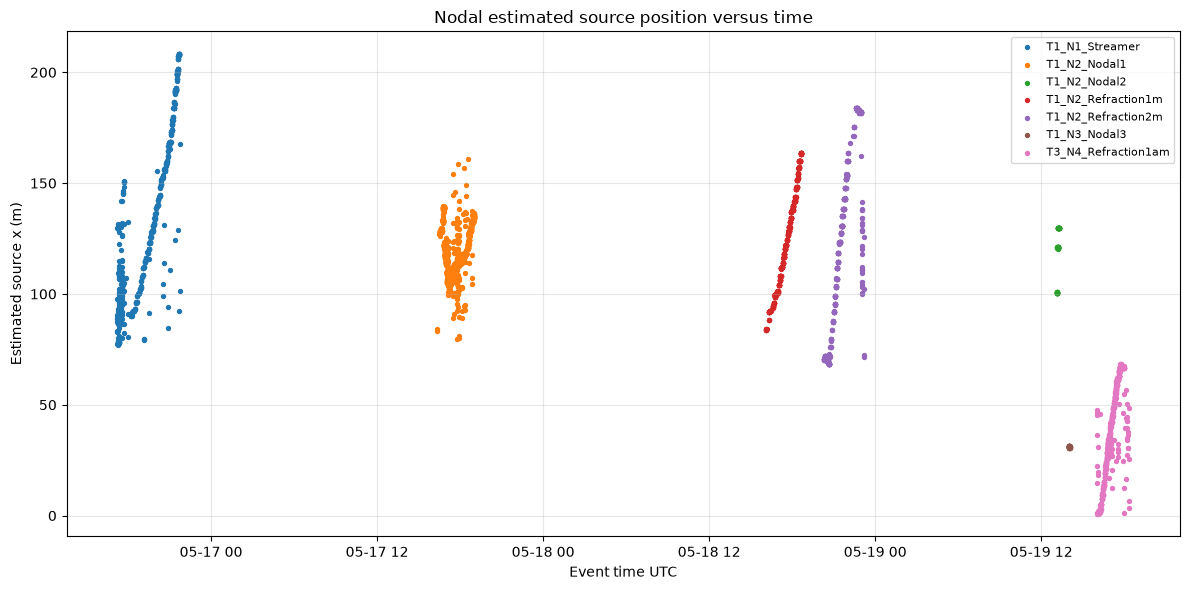

,count,mean,std,min,25%,50%,75%,max
timewindow_label,,,,,,,,
T1_N1_Streamer,532.0,137.117443,39.365661,77.155375,101.248907,131.548465,168.452494,208.138530
T1_N2_Nodal1,1376.0,117.927386,10.941891,79.624112,109.640254,116.355411,126.630252,160.875690
T1_N2_Nodal2,81.0,119.202117,11.400299,100.281721,120.492644,121.013288,129.783382,129.902663
T1_N2_Refraction1m,431.0,124.918880,22.439328,83.821893,106.084149,124.197145,141.826622,163.527304
T1_N2_Refraction2m,450.0,122.314323,38.038981,68.205419,87.781801,123.411771,151.823263,183.864698
T1_N3_Nodal3,43.0,31.030022,0.271161,30.437641,30.874994,31.016381,31.204980,31.540962
T3_N4_Refraction1am,523.0,37.389386,21.357064,0.928637,21.096273,35.190638,57.337815,68.280185


In [21]:
plot_df = source_estimates.copy()
plot_df["event_time_dt"] = pd.to_datetime(plot_df["event_time_utc"], errors="coerce", utc=True)
plot_df["estimated_source_x_m"] = pd.to_numeric(plot_df["estimated_source_x_m"], errors="coerce")

# Canonical acquisition palette shared with notebooks 92 and 94.
TIMEWINDOW_COLORS = {
    "T1_N1_Streamer": "#1f77b4",
    "T1_N2_Nodal1": "#ff7f0e",
    "T1_N2_Nodal2": "#2ca02c",
    "T1_N2_Refraction1m": "#d62728",
    "T1_N2_Refraction2m": "#9467bd",
    "T1_N3_Nodal3": "#8c564b",
    "T3_N4_Refraction1am": "#e377c2",
}
DEFAULT_SERIES_COLOR = "#7f7f7f"

fig, ax = plt.subplots(figsize=(12, 6))
for label, sub in plot_df.dropna(subset=["event_time_dt", "estimated_source_x_m"]).groupby("timewindow_label"):
    ax.scatter(
        sub["event_time_dt"],
        sub["estimated_source_x_m"],
        s=8,
        color=TIMEWINDOW_COLORS.get(str(label), DEFAULT_SERIES_COLOR),
        label=label,
    )

ax.set_title("Nodal estimated source position versus time")
ax.set_xlabel("Event time UTC")
ax.set_ylabel("Estimated source x (m)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

display(plot_df.groupby("timewindow_label")["estimated_source_x_m"].describe())